Mean Squared Error: 15.15
Root Mean Squared Error: 3.89
R² Score: 0.74


/tmp/ipykernel_52456/3530881004.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['horsepower'].fillna(value=X['horsepower'].mean(), inplace=True)


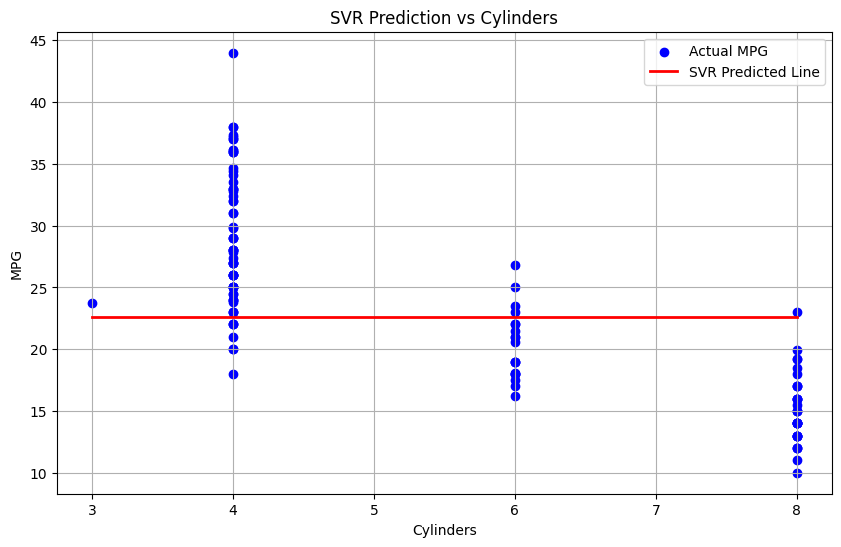

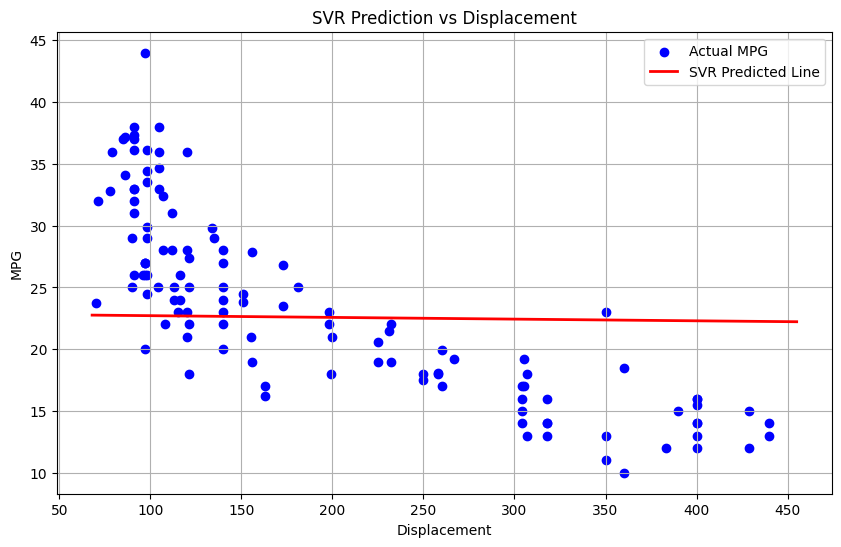

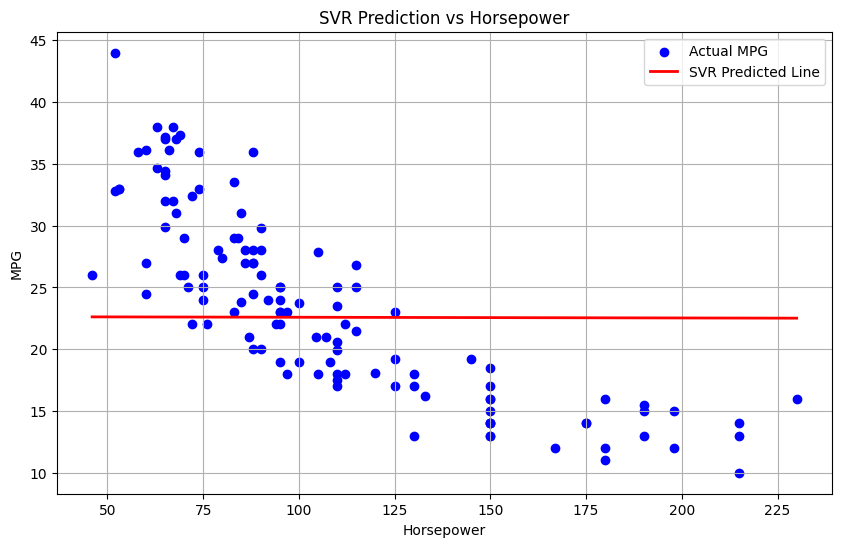

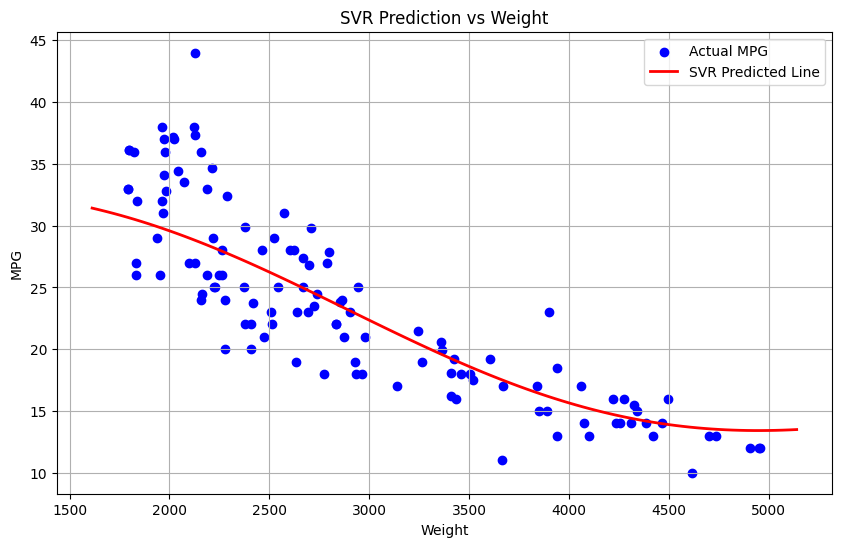

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
# Load dataset
mpg = fetch_ucirepo(id=9)
# Create DataFrame
X = pd.DataFrame(data=mpg.data.features, columns=list(mpg.data.headers)[1:-1])
y = pd.DataFrame(data=mpg.data.targets, columns=[list(mpg.data.headers)[-1]])
# Handle missing values
X['horsepower'] = pd.to_numeric(X['horsepower'], errors='coerce')
X['horsepower'].fillna(value=X['horsepower'].mean(), inplace=True)
# Select features
X_filtered = X[["cylinders", "displacement", "horsepower", "weight"]]
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.3, random_state=42)
# Fit SVR model
svr_model = SVR(kernel="rbf")
svr_model.fit(X_train, y_train.values.ravel())
# Predict
y_pred = svr_model.predict(X_test)
# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
# --- Visualization: SVR Regression Line vs Horsepower ---
for feature in ["cylinders", "displacement", "horsepower", "weight"]:
   # Generate values for horsepower across its range
   feature_range = np.linspace(X_filtered[feature].min(), X_filtered[feature].max(), 100)
   # Fix all other features to their mean values
   base_input = X_filtered.mean().to_dict()
   # Create DataFrame where only 'horsepower' varies
   X_vis = pd.DataFrame([base_input] * len(feature_range))
   X_vis[feature] = feature_range
   # Predict with SVR model
   y_vis_pred = svr_model.predict(X_vis)
   # Plot actual vs predicted
   plt.figure(figsize=(10, 6))
   plt.scatter(X_test[feature], y_test, color='blue', label='Actual MPG')
   plt.plot(feature_range, y_vis_pred, color='red', linewidth=2, label='SVR Predicted Line')
   plt.xlabel(feature.capitalize())
   plt.ylabel("MPG")
   plt.title(f"SVR Prediction vs {feature.capitalize()}")
   plt.legend()
   plt.grid(True)
   plt.show()